# DBSCAN - Synthetic dataset with make_moons function

# Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Step 2: Generating sample data

In [2]:
# The make_moons function in sklearn.datasets generates a synthetic dataset consisting of two interleaving half-circles, often referred to as "moons."
X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
X

array([[-1.02069027e+00,  1.05517543e-01],
       [ 9.05826497e-01,  4.57857514e-01],
       [ 6.18421752e-01,  7.57086323e-01],
       [ 1.22770701e+00, -4.25185116e-01],
       [ 3.29355941e-01, -2.06945678e-01],
       [ 1.81424817e-01,  1.11389766e-01],
       [-6.24088950e-01,  8.18420699e-01],
       [ 1.58093806e+00, -2.49603710e-01],
       [ 1.78680514e+00, -1.69014701e-01],
       [ 1.42772056e-01,  9.71544477e-01],
       [-4.67545663e-01,  8.04881727e-01],
       [ 1.88480021e+00, -5.94119381e-02],
       [ 1.50329849e+00, -3.89500232e-01],
       [-8.05466315e-01,  5.73883368e-01],
       [ 1.89827121e+00,  1.26875555e-01],
       [ 1.81823747e+00, -1.16465202e-01],
       [-1.36612342e-01,  1.10576058e+00],
       [ 1.06302541e+00, -5.07148112e-01],
       [-9.29985486e-01,  5.73213754e-01],
       [-4.88950223e-01,  7.89212547e-01],
       [ 3.07148004e-01, -1.29225472e-01],
       [ 8.85163791e-01,  5.28566808e-01],
       [ 9.61159735e-01, -5.59710084e-01],
       [-9.

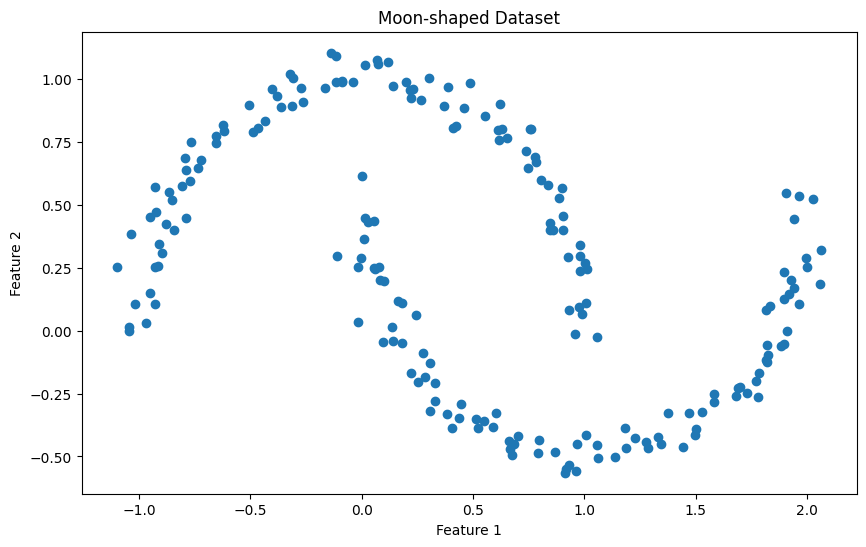

In [3]:
# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Step 3: Choosing MinPts and Epsilon Value

### MinPts

*   min. points >= data dimensions + 1



## Epsilon Value with K-distance Plot

In [4]:
# extract the distances and indices of each point with kneighbors() method:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5) # minimum points -1
nbrs = nn.fit(X)
distances, indices = nbrs.kneighbors(X)

In [5]:
# After finding the distances, sort them from smallest to largest.
distances = np.sort(distances, axis=0)
distances

array([[0.        , 0.00429189, 0.02039092, 0.03048454, 0.0439404 ],
       [0.        , 0.00429189, 0.02146649, 0.03662899, 0.05413024],
       [0.        , 0.00644575, 0.02153485, 0.03927062, 0.0542347 ],
       [0.        , 0.00644575, 0.02330833, 0.03974037, 0.05717184],
       [0.        , 0.00652338, 0.02330833, 0.03986668, 0.0575334 ],
       [0.        , 0.00652338, 0.02543395, 0.04050537, 0.05885191],
       [0.        , 0.00658094, 0.0262185 , 0.04220828, 0.059944  ],
       [0.        , 0.00658094, 0.0262185 , 0.04287351, 0.06008337],
       [0.        , 0.00997374, 0.02711298, 0.04438257, 0.06046721],
       [0.        , 0.00997374, 0.02788262, 0.04480051, 0.06123269],
       [0.        , 0.01343417, 0.02870947, 0.04577076, 0.06194091],
       [0.        , 0.01343417, 0.02870947, 0.04641063, 0.06248646],
       [0.        , 0.01352264, 0.02960594, 0.0472521 , 0.06475093],
       [0.        , 0.01352264, 0.02993356, 0.0472521 , 0.06512166],
       [0.        , 0.01432943, 0.

In [6]:
# Choosing only the largest distances
distances = distances[:,-1]
distances

array([0.0439404 , 0.05413024, 0.0542347 , 0.05717184, 0.0575334 ,
       0.05885191, 0.059944  , 0.06008337, 0.06046721, 0.06123269,
       0.06194091, 0.06248646, 0.06475093, 0.06512166, 0.06525021,
       0.06608327, 0.0664263 , 0.067359  , 0.06858648, 0.06865902,
       0.06870094, 0.06870094, 0.06886279, 0.06930529, 0.06930529,
       0.07044676, 0.07089071, 0.07089775, 0.07089775, 0.07150496,
       0.07150496, 0.0720115 , 0.07233985, 0.07366649, 0.07373696,
       0.07403353, 0.07475099, 0.07493901, 0.07493901, 0.07517617,
       0.07598765, 0.07622618, 0.07727905, 0.07904739, 0.07904739,
       0.07935806, 0.07953701, 0.07991032, 0.08023308, 0.08055669,
       0.08080619, 0.08083083, 0.08089295, 0.08119295, 0.08127954,
       0.08306984, 0.08314695, 0.08314695, 0.08315283, 0.08459361,
       0.08459361, 0.08491171, 0.08502733, 0.08525623, 0.08529815,
       0.08603868, 0.08644314, 0.08665013, 0.08700568, 0.08758355,
       0.0882326 , 0.08959453, 0.0900345 , 0.09015765, 0.09036

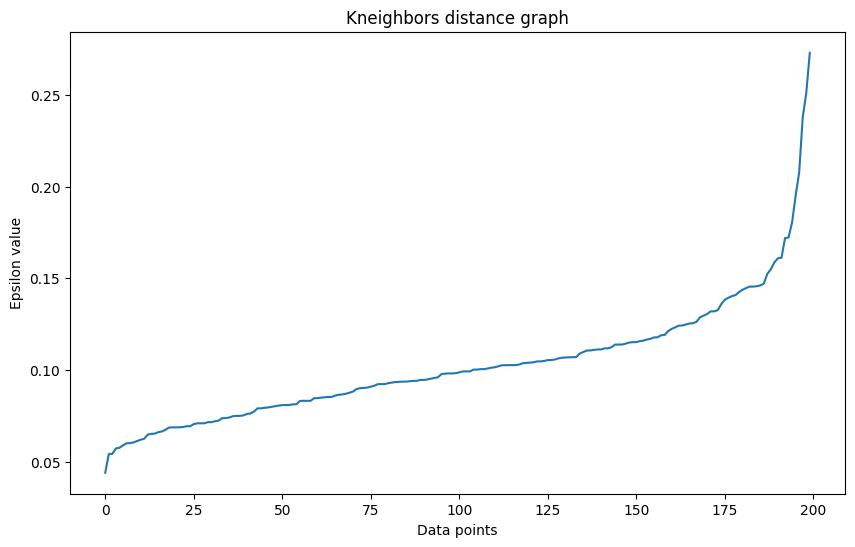

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title('Kneighbors distance graph')
plt.xlabel('Data points')
plt.ylabel('Epsilon value')
plt.show();

# Step 5: Implementing DBSCAN Clustering

In [8]:
import pandas as pd

df = pd.DataFrame(X)
df.head()

,0,1
0,-1.020690,0.105518
1,0.905826,0.457858
2,0.618422,0.757086
3,1.227707,-0.425185
4,0.329356,-0.206946


In [9]:
from sklearn.cluster import DBSCAN

# min_samples == minimum points ≥ dataset_dimensions + 1
dbs = DBSCAN(eps=0.15, min_samples=5)
dbs.fit(df)

# Add the cluster labels to scaled data
dbscan_labels = dbs.labels_
df['dbscan_labels'] = dbscan_labels
df.head()

,0,1,dbscan_labels
0,-1.020690,0.105518,0
1,0.905826,0.457858,0
2,0.618422,0.757086,0
3,1.227707,-0.425185,1
4,0.329356,-0.206946,1


In [10]:
# labels with -1 values are the noise points that not belong to any cluster.
# Show Number of noise points
labels_list = list(df['dbscan_labels'])
n_noise = labels_list.count(-1)
print("Number of noise points:", n_noise)

Number of noise points: 5


In [11]:
# Show Number of clusters
import numpy as np
total_labels = np.unique(dbscan_labels)

n_labels = 0
for n in total_labels:
    if n != -1:
        n_labels += 1
print("Number of clusters:", n_labels)

Number of clusters: 2


In [12]:
df.head()

,0,1,dbscan_labels
0,-1.020690,0.105518,0
1,0.905826,0.457858,0
2,0.618422,0.757086,0
3,1.227707,-0.425185,1
4,0.329356,-0.206946,1


In [13]:
df[df['dbscan_labels'] == -1]

,0,1,dbscan_labels
41,2.029490,0.524723,-1
45,1.944004,0.442508,-1
78,0.002925,0.617400,-1
112,1.966285,0.536278,-1
191,1.904311,0.547064,-1


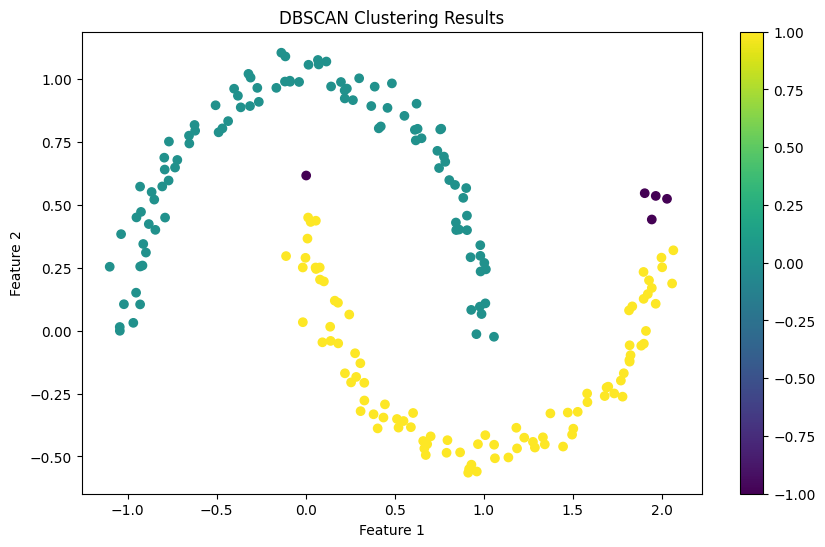

In [14]:
# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Clustering Performance Evaluation

In [15]:
X_features = df.iloc[:, :-1]
X_features.head()

,0,1
0,-1.020690,0.105518
1,0.905826,0.457858
2,0.618422,0.757086
3,1.227707,-0.425185
4,0.329356,-0.206946


## Silhouette Score

In [16]:
from sklearn.metrics import silhouette_score
s_score = silhouette_score(X_features, dbscan_labels)
print(f"Silhouette coefficient: {s_score:.3f}")

Silhouette coefficient: 0.221


## Davies-Bouldin Index (DBI)

In [17]:
from sklearn.metrics import davies_bouldin_score
dbi_score = davies_bouldin_score(X_features, dbscan_labels)
print(f"Davies-Bouldin Index: {dbi_score:.3f}")

Davies-Bouldin Index: 1.362


## Calinski-Harabasz Index (CHI)

In [18]:
from sklearn.metrics import calinski_harabasz_score
chi_score = calinski_harabasz_score(X_features, dbscan_labels)
print(f"Calinski-Harabasz Index: {chi_score:.3f}")

Calinski-Harabasz Index: 68.694


# Compare with K-Means

In [19]:
kmeans_df = df.iloc[:, :-1]
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)
kmeans_labels = kmeans.fit_predict(X)

dbscan_labels = dbs.labels_
kmeans_df['kmeans_labels'] = dbscan_labels
kmeans_df.head()

,0,1,kmeans_labels
0,-1.020690,0.105518,0
1,0.905826,0.457858,0
2,0.618422,0.757086,0
3,1.227707,-0.425185,1
4,0.329356,-0.206946,1


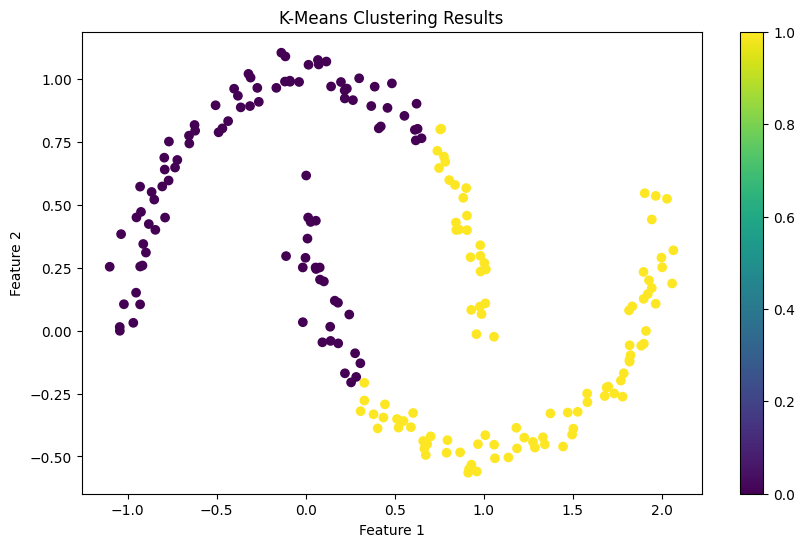

In [20]:
# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.colorbar(scatter)
plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [21]:
s_score = silhouette_score(X_features, kmeans_labels)
print(f"Silhouette coefficient: {s_score:.3f}")

dbi_score = davies_bouldin_score(X_features, kmeans_labels)
print(f"Davies-Bouldin Index: {dbi_score:.3f}")

chi_score = calinski_harabasz_score(X_features, kmeans_labels)
print(f"Calinski-Harabasz Index: {chi_score:.3f}")

Silhouette coefficient: 0.483
Davies-Bouldin Index: 0.785
Calinski-Harabasz Index: 291.217


# Density-Based Clustering Validation (DBCV)
```
!pip install hdbscan
```
```
from hdbscan.validity import validity_index
```